In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gc
import os

import sklearn
from sklearn.utils.class_weight import compute_class_weight
import imblearn
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 불러오기
train_df = pd.read_csv('../data/final_train.csv')

# 공통 설정
FEATURES = [col for col in train_df.columns if col not in ["ID", "Segment"]]

SAVE_PATH = "./models"
os.makedirs(SAVE_PATH, exist_ok=True)

In [12]:
def train_eval_xgb(df, features, label_col='target', model_name='model', save_path="./models", use_gpu=True):
    os.makedirs(save_path, exist_ok=True)

    # 클래스 인코딩
    class_map = {label: i for i, label in enumerate(sorted(df[label_col].unique()))}
    inv_class_map = {v: k for k, v in class_map.items()}
    y = df[label_col].map(class_map)
    X = df[features]

    # train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 클래스 가중치
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    sample_weights = y_train.map(dict(zip(classes, weights)))

    # 모델 정의
    model = xgb.XGBClassifier(
        objective='multi:softprob' if len(classes) > 2 else 'binary:logistic',
        num_class=len(classes) if len(classes) > 2 else None,
        eval_metric='mlogloss',
        n_estimators=500,
        tree_method='hist',
        device='cuda' if use_gpu else 'auto',
        random_state=42
    )

    # 학습
    model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)

    # 검증 예측
    y_pred = model.predict(X_val)

    # Classification Report
    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_val, y_pred, target_names=[inv_class_map[c] for c in classes]))

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[inv_class_map[c] for c in classes])
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix (Validation)")
    plt.show()

    # Feature Importance
    importance = model.feature_importances_
    imp_df = pd.DataFrame({'feature': features, 'importance': importance})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(imp_df['feature'], imp_df['importance'])
    plt.gca().invert_yaxis()
    plt.title(f"{model_name} Top 20 Feature Importance")
    plt.show()

    # 모델 저장
    joblib.dump((model, class_map), f"{save_path}/{model_name}.pkl")

    return model, class_map, imp_df


Classification Report for model1
              precision    recall  f1-score   support

           E       0.98      0.91      0.94    384410
       not_E       0.72      0.91      0.80     95590

    accuracy                           0.91    480000
   macro avg       0.85      0.91      0.87    480000
weighted avg       0.92      0.91      0.92    480000



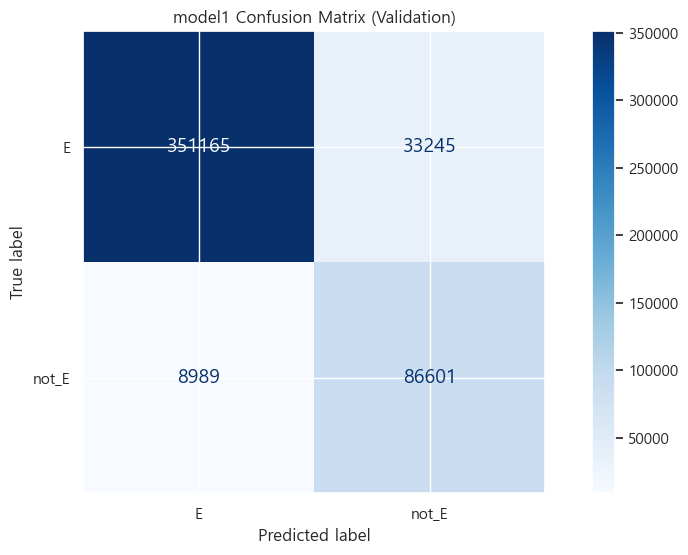

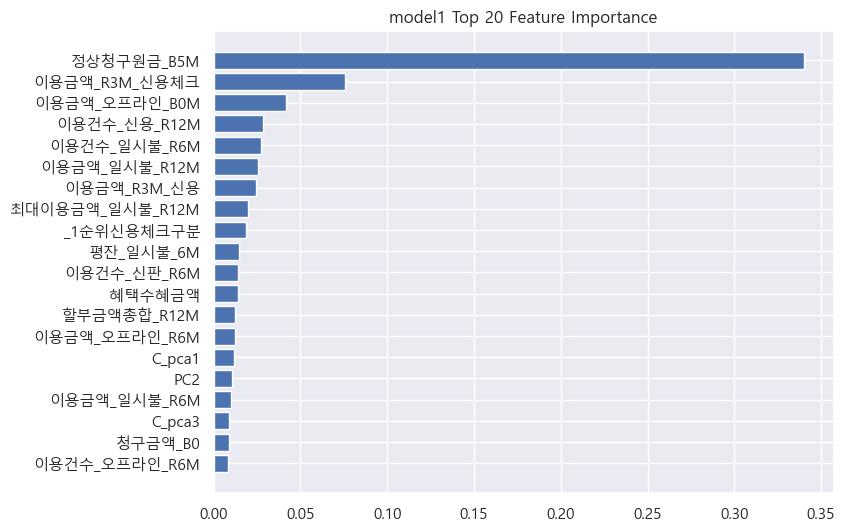


Classification Report for model2
              precision    recall  f1-score   support

          CD       1.00      1.00      1.00     95367
      not_CD       0.72      0.73      0.73       223

    accuracy                           1.00     95590
   macro avg       0.86      0.87      0.86     95590
weighted avg       1.00      1.00      1.00     95590



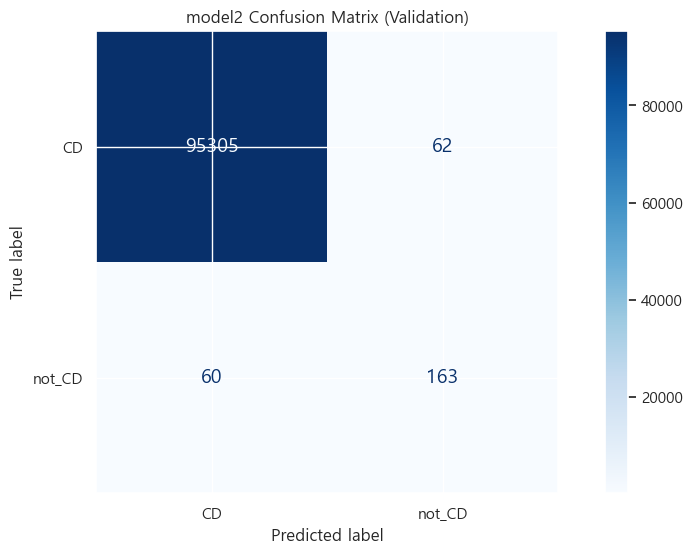

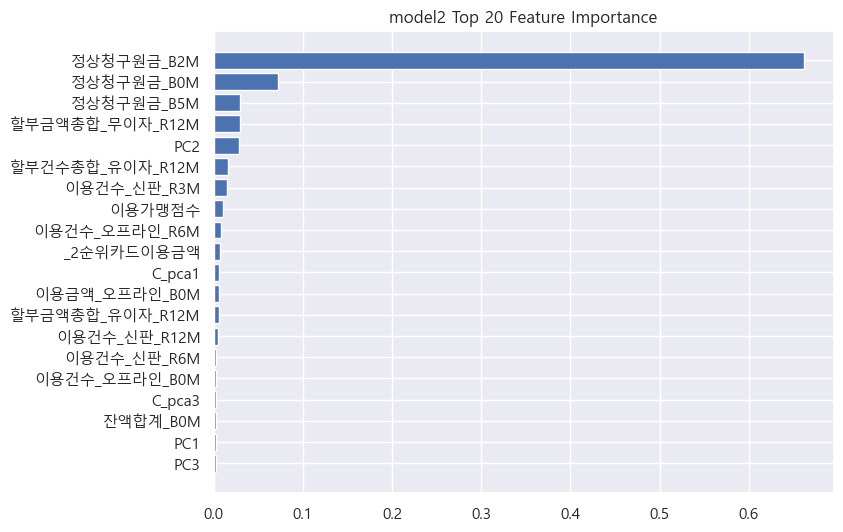


Classification Report for model3
              precision    recall  f1-score   support

           A       0.99      0.98      0.98       195
           B       0.87      0.93      0.90        29

    accuracy                           0.97       224
   macro avg       0.93      0.96      0.94       224
weighted avg       0.97      0.97      0.97       224



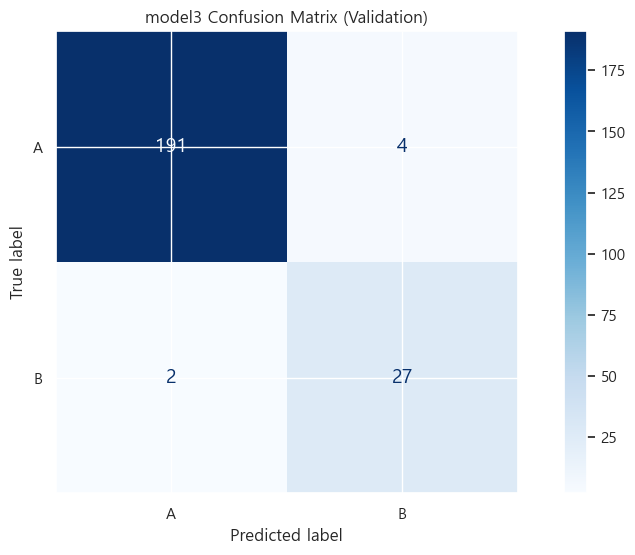

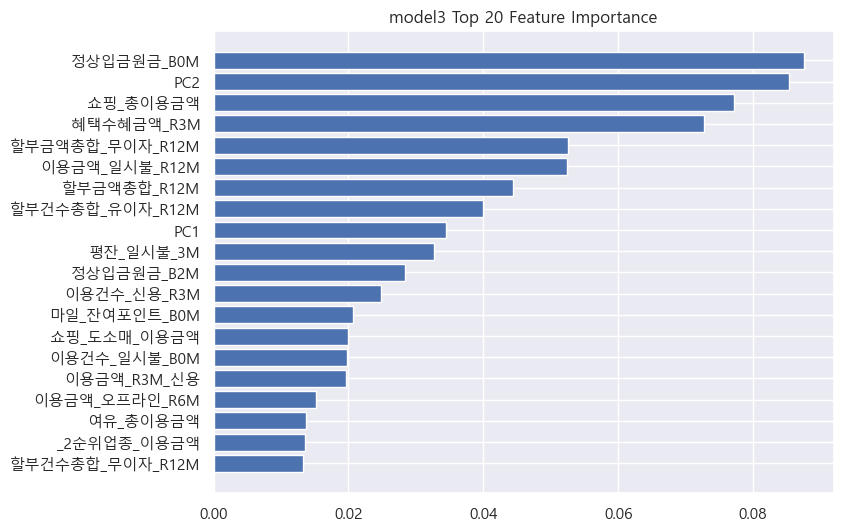

In [14]:
train_df = pd.read_csv('../data/final_train.csv')
FEATURES = [col for col in train_df.columns if col not in ["ID", "Segment"]]

dataset1 = prepare_dataset(train_df.copy(), 'E_vs_notE')
dataset2 = prepare_dataset(train_df.copy(), 'CD_vs_notCD')
dataset3 = prepare_dataset(train_df.copy(), 'A_vs_B')

model1, map1, imp1 = train_eval_xgb(dataset1, FEATURES, model_name='model1')
model2, map2, imp2 = train_eval_xgb(dataset2, FEATURES, model_name='model2')
model3, map3, imp3 = train_eval_xgb(dataset3, FEATURES, model_name='model3')

### 예측하기

In [3]:
# 데이터 불러오기
train_df = pd.read_csv('../data/final_train.csv')

# 공통 설정
FEATURES = [col for col in train_df.columns if col not in ["ID", "Segment"]]

SAVE_PATH = "./models"
os.makedirs(SAVE_PATH, exist_ok=True)

In [26]:
train_df['ID']

0          TRAIN_000000
1          TRAIN_000001
2          TRAIN_000002
3          TRAIN_000003
4          TRAIN_000004
               ...     
2399995    TRAIN_399995
2399996    TRAIN_399996
2399997    TRAIN_399997
2399998    TRAIN_399998
2399999    TRAIN_399999
Name: ID, Length: 2400000, dtype: object

In [ ]:
def train_eval_xgb(df, features, label_col='target', model_name='model', save_path="./models", use_gpu=True):
    os.makedirs(save_path, exist_ok=True)

    # 클래스 인코딩
    class_map = {label: i for i, label in enumerate(sorted(df[label_col].unique()))}
    inv_class_map = {v: k for k, v in class_map.items()}
    y = df[label_col].map(class_map)
    X = df[features]

    # train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 클래스 가중치
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train.map(weight_dict).values

    # 모델 정의
    params = {
        "objective": 'multi:softprob' if len(classes) > 2 else 'binary:logistic',
        "eval_metric": 'mlogloss',
        "n_estimators": 500,
        "tree_method": 'hist',
        "device": 'cuda' if use_gpu else 'auto',
        "random_state": 42
    }
    if len(classes) > 2:
        params["num_class"] = len(classes)

    model = xgb.XGBClassifier(**params)

    # 학습
    model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)

    # 예측 및 평가
    y_pred = model.predict(X_val)

    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_val, y_pred, target_names=[inv_class_map[c] for c in classes]))

    # 혼동 행렬 시각화
    cm = confusion_matrix(y_val, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[inv_class_map[c] for c in classes])
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # feature importance
    booster = model.get_booster()
    importance_dict = booster.get_score(importance_type='gain')  # gain 기반
    imp_df = pd.DataFrame({
        'feature': list(importance_dict.keys()),
        'importance': list(importance_dict.values())
    }).sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(imp_df['feature'], imp_df['importance'])
    plt.gca().invert_yaxis()
    plt.title(f"{model_name} Top 20 Feature Importance (gain)")
    plt.show()

    # 모델 저장
    joblib.dump((model, class_map), f"{save_path}/{model_name}.pkl")

    return model, class_map, imp_df

c:\Users\COTTA\anaconda3\Lib\site-packages\xgboost\core.py:729: UserWarning: [16:58:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Classification Report for model1
              precision    recall  f1-score   support

           E       0.98      0.91      0.94    384410
       not_E       0.72      0.91      0.80     95590

    accuracy                           0.91    480000
   macro avg       0.85      0.91      0.87    480000
weighted avg       0.92      0.91      0.92    480000



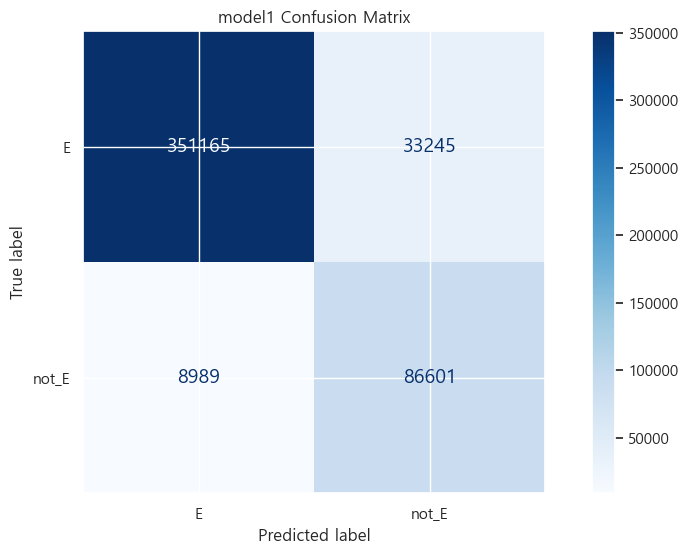

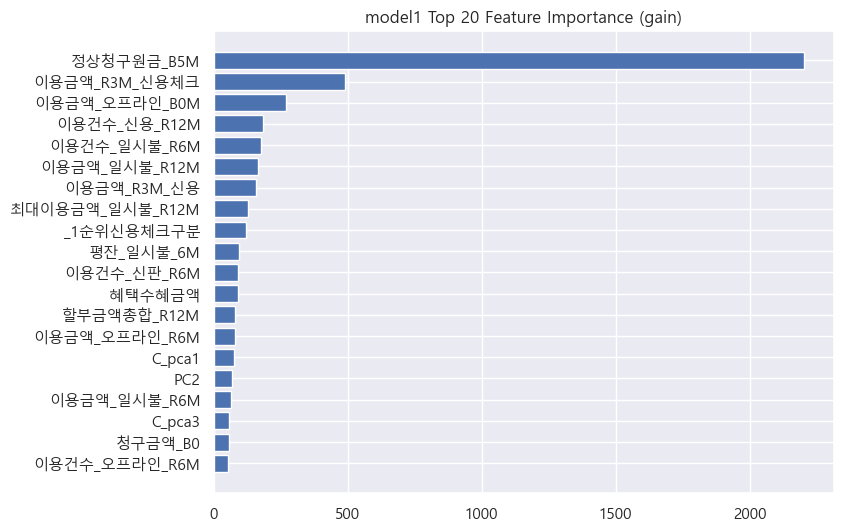


Classification Report for model2
              precision    recall  f1-score   support

           C       0.71      0.82      0.76     25518
           D       0.93      0.88      0.90     69849
       Other       0.85      0.70      0.77       223

    accuracy                           0.86     95590
   macro avg       0.83      0.80      0.81     95590
weighted avg       0.87      0.86      0.86     95590



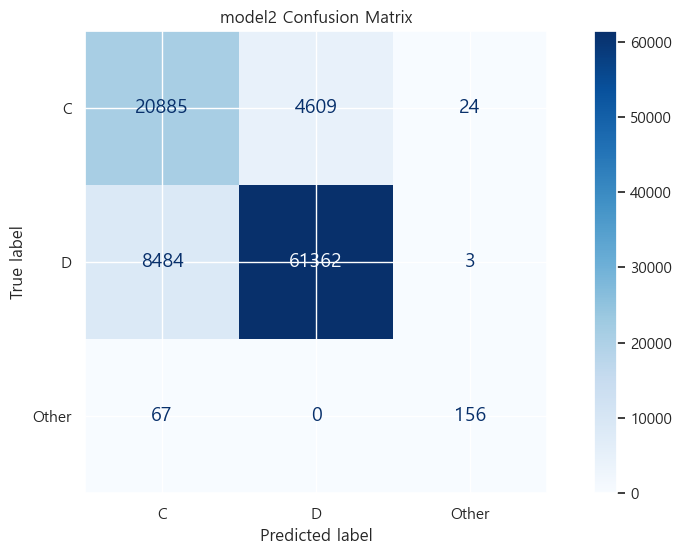

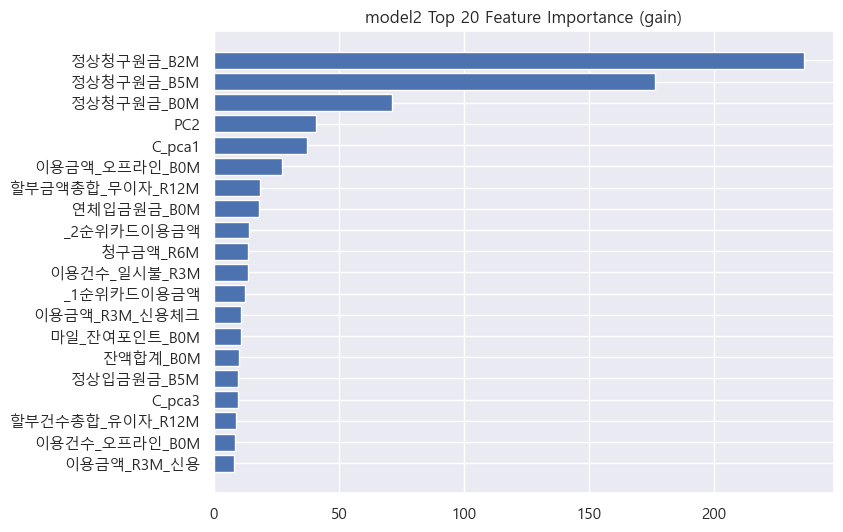


Classification Report for model3
              precision    recall  f1-score   support

           A       0.99      0.98      0.98       195
           B       0.87      0.93      0.90        29

    accuracy                           0.97       224
   macro avg       0.93      0.96      0.94       224
weighted avg       0.97      0.97      0.97       224



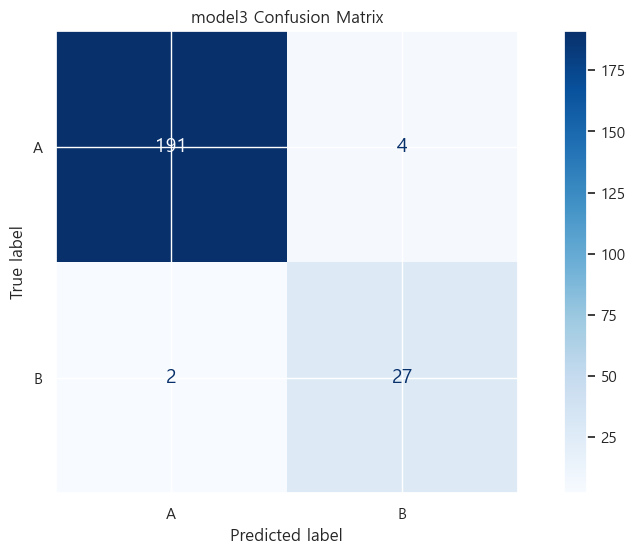

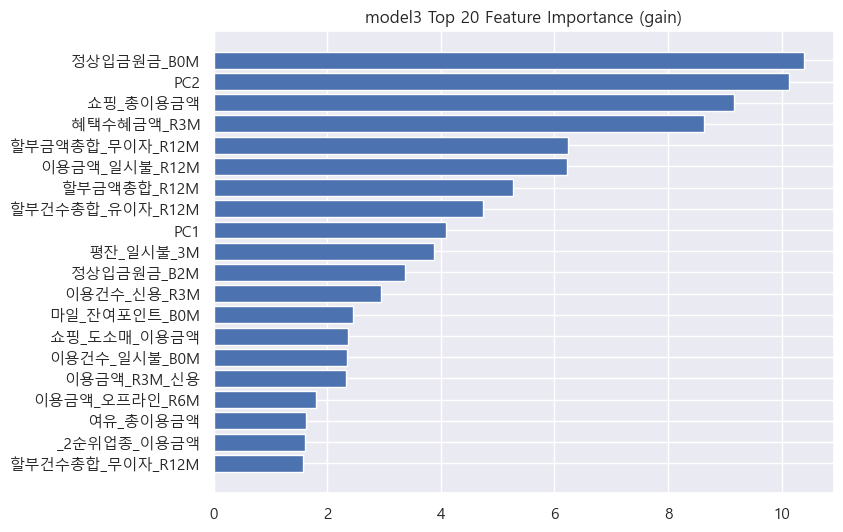

In [5]:
# Dataset1: E vs not-E
df1 = train_df.copy()
df1['target'] = df1['Segment'].apply(lambda x: 'E' if x == 'E' else 'not_E')
model1, map1, imp1 = train_eval_xgb(df1, features=FEATURES, model_name='model1')

# Dataset2: C, D, Other
df2 = train_df[train_df['Segment'] != 'E'].copy()
df2['target'] = df2['Segment'].apply(lambda x: x if x in ['C', 'D'] else 'Other')
model2, map2, imp2 = train_eval_xgb(df2, features=FEATURES, model_name='model2')

# Dataset3: A vs B
df3 = train_df[train_df['Segment'].isin(['A', 'B'])].copy()
df3['target'] = df3['Segment']
model3, map3, imp3 = train_eval_xgb(df3, features=FEATURES, model_name='model3')


In [8]:
# 모델 불러오기
model1, map1 = joblib.load('./models/model1.pkl')  # E vs not-E
model2, map2 = joblib.load('./models/model2.pkl')  # C vs D vs Other
model3, map3 = joblib.load('./models/model3.pkl')  # A vs B

# 테스트 데이터 로드
test_df = pd.read_csv("../data/final_test.csv").reset_index(drop=True)
FEATURES = [col for col in test_df.columns if col not in ["ID", "Segment"]]
X_test = test_df[FEATURES]

# 1단계: E vs not-E
y1_pred = model1.predict(X_test)
inv_map1 = {v: k for k, v in map1.items()}
y1_label = pd.Series(y1_pred, index=test_df.index).map(inv_map1)

# 결과 초기화
final_preds = pd.Series(index=test_df.index, dtype='object')
final_preds[y1_label == 'E'] = 'E'

# 2단계: not-E 데이터 -> C, D, Other(A/B)
idx_not_e = y1_label != 'E'
X_not_e = X_test.loc[idx_not_e]
y2_pred = model2.predict(X_not_e)
inv_map2 = {v: k for k, v in map2.items()}
y2_label = pd.Series(y2_pred, index=X_not_e.index).map(inv_map2)

# C, D는 바로 결과로 확정
final_preds.loc[y2_label.index[y2_label == 'C']] = 'C'
final_preds.loc[y2_label.index[y2_label == 'D']] = 'D'

# 3단계: A/B 분류
idx_ab = y2_label[~y2_label.isin(['C', 'D'])].index
X_ab = X_test.loc[idx_ab]
y3_pred = model3.predict(X_ab)
inv_map3 = {v: k for k, v in map3.items()}
y3_label = pd.Series(y3_pred, index=X_ab.index).map(inv_map3)

# A, B 결과 반영
final_preds.loc[y3_label.index] = y3_label

In [18]:
test_df

,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,_1순위신용체크구분,_2순위카드이용금액,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용금액_일시불_B0M,이용건수_신용_R12M,...,할부금액총합_유이자_R12M,할부건수총합_무이자_R12M,할부금액총합_무이자_R12M,잔액합계_B0M,연체합계_B0M,월중평잔_합계,청구서발송여부_all,청구금액_PCA,ID,pred_label
0,21458,21458,13852,2,6021,28,28,28,7650,150,...,0,0,0,4802,0,10730,1,-0.238548,TEST_00000,E
1,18681,10759,11065,2,0,8,8,6,367,28,...,9249,23,17396,39576,0,93545,1,0.496369,TEST_00001,E
2,40758,40758,27071,2,10704,59,59,59,8547,650,...,11073,9,20756,9190,0,34547,1,1.924003,TEST_00002,D
3,5255,5255,4827,2,0,37,37,37,1270,361,...,3803,0,5136,1713,0,4681,1,-0.816754,TEST_00003,E
4,16148,14290,8011,2,6387,19,19,18,709,227,...,4099,8,9884,3195,0,10872,1,-0.526291,TEST_00004,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,0,0,0,-1,-1,-1,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_99995,E
599996,3110,3110,1231,2,0,0,0,0,-121,7,...,0,0,0,191,0,563,1,-1.060937,TEST_99996,E
599997,0,0,0,2,0,3,3,3,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_99997,E
599998,173263,113786,63592,2,31916,78,78,78,22617,933,...,0,4,12508,20702,0,29986,1,2.885235,TEST_99998,C


In [19]:
# 2. 예측 결과 할당
test_df["pred_label"] = final_preds.values  # final_preds: 600,000개의 예측값

# 3. ID별 최빈값 집계
submission = test_df.groupby("ID")["pred_label"] \
    .agg(lambda x: x.value_counts().idxmax()) \
    .reset_index()

submission.columns = ["ID", "Segment"]

# 4. 저장
submission.to_csv("../data/submission_final.csv", index=False, encoding="utf-8-sig")
print("10만 명 사용자 기준 최빈값 제출 완료")

10만 명 사용자 기준 최빈값 제출 완료


In [18]:
print(test_df.columns)

Index(['이용금액_R3M_신용체크', '이용금액_R3M_신용', '_1순위카드이용금액', '_1순위신용체크구분',
       '_2순위카드이용금액', '이용건수_신용_B0M', '이용건수_신판_B0M', '이용건수_일시불_B0M',
       '이용금액_일시불_B0M', '이용건수_신용_R12M', '이용건수_신판_R12M', '이용건수_일시불_R12M',
       '이용금액_일시불_R12M', '최대이용금액_일시불_R12M', '이용건수_신용_R6M', '이용건수_신판_R6M',
       '이용건수_일시불_R6M', '이용금액_일시불_R6M', '이용건수_신용_R3M', '이용건수_신판_R3M',
       '이용건수_일시불_R3M', '이용금액_일시불_R3M', '이용가맹점수', '쇼핑_도소매_이용금액', '_1순위업종_이용금액',
       '_2순위업종_이용금액', '_3순위업종_이용금액', '_2순위쇼핑업종_이용금액', '_3순위쇼핑업종_이용금액',
       '_1순위교통업종_이용금액', '이용금액_오프라인_R6M', '이용건수_오프라인_R6M', '이용금액_오프라인_R3M',
       '이용건수_오프라인_R3M', '이용금액_오프라인_B0M', '이용건수_오프라인_B0M', '정상청구원금_B0M',
       '정상입금원금_B0M', '연체입금원금_B0M', '정상청구원금_B2M', '정상입금원금_B2M', '정상청구원금_B5M',
       '정상입금원금_B5M', '청구금액_B0', '청구금액_R3M', '청구금액_R6M', '마일_잔여포인트_B0M',
       '혜택수혜금액_R3M', '포인트_마일리지_환산_B0M', '혜택수혜금액', '잔액_일시불_B0M', '월중평잔_일시불_B0M',
       '월중평잔_일시불', '평잔_일시불_3M', '평잔_일시불_6M', 'PC1', 'PC2', 'PC3', 'C_pca1',
       'C_pca2', 'C_pca3', '건수별평균이용금액_온라인_R6M', '건

In [10]:
test_df

,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,_1순위신용체크구분,_2순위카드이용금액,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용금액_일시불_B0M,이용건수_신용_R12M,...,할부금액총합_유이자_R12M,할부건수총합_무이자_R12M,할부금액총합_무이자_R12M,잔액합계_B0M,연체합계_B0M,월중평잔_합계,청구서발송여부_all,청구금액_PCA,ID,pred_label
0,21458,21458,13852,2,6021,28,28,28,7650,150,...,0,0,0,4802,0,10730,1,-0.238548,TEST_00000,E
1,18681,10759,11065,2,0,8,8,6,367,28,...,9249,23,17396,39576,0,93545,1,0.496369,TEST_00000,E
2,40758,40758,27071,2,10704,59,59,59,8547,650,...,11073,9,20756,9190,0,34547,1,1.924003,TEST_00000,D
3,5255,5255,4827,2,0,37,37,37,1270,361,...,3803,0,5136,1713,0,4681,1,-0.816754,TEST_00000,E
4,16148,14290,8011,2,6387,19,19,18,709,227,...,4099,8,9884,3195,0,10872,1,-0.526291,TEST_00000,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,0,0,0,-1,-1,-1,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_59999,E
599996,3110,3110,1231,2,0,0,0,0,-121,7,...,0,0,0,191,0,563,1,-1.060937,TEST_59999,E
599997,0,0,0,2,0,3,3,3,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_59999,E
599998,173263,113786,63592,2,31916,78,78,78,22617,933,...,0,4,12508,20702,0,29986,1,2.885235,TEST_59999,C


In [13]:
# ID 컬럼만 불러오기
id_df = pd.read_csv("../data/test/1_회원정보_test.csv", usecols=["ID"])

In [14]:
id_df

,ID
0,TEST_00000
1,TEST_00001
2,TEST_00002
3,TEST_00003
4,TEST_00004
...,...
599995,TEST_99995
599996,TEST_99996
599997,TEST_99997
599998,TEST_99998


In [ ]:
# ID 컬럼만 불러오기
id_df = pd.read_csv("../data/test/1_회원정보_test.csv", usecols=["ID"])
# 기존 test_df에 ID 컬럼 붙이기 (행 수가 같다는 전제)
test_df["ID"] = id_df["ID"].values

In [17]:
test_df

,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,_1순위신용체크구분,_2순위카드이용금액,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용금액_일시불_B0M,이용건수_신용_R12M,...,할부금액총합_유이자_R12M,할부건수총합_무이자_R12M,할부금액총합_무이자_R12M,잔액합계_B0M,연체합계_B0M,월중평잔_합계,청구서발송여부_all,청구금액_PCA,ID,pred_label
0,21458,21458,13852,2,6021,28,28,28,7650,150,...,0,0,0,4802,0,10730,1,-0.238548,TEST_00000,E
1,18681,10759,11065,2,0,8,8,6,367,28,...,9249,23,17396,39576,0,93545,1,0.496369,TEST_00001,E
2,40758,40758,27071,2,10704,59,59,59,8547,650,...,11073,9,20756,9190,0,34547,1,1.924003,TEST_00002,D
3,5255,5255,4827,2,0,37,37,37,1270,361,...,3803,0,5136,1713,0,4681,1,-0.816754,TEST_00003,E
4,16148,14290,8011,2,6387,19,19,18,709,227,...,4099,8,9884,3195,0,10872,1,-0.526291,TEST_00004,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,0,0,0,-1,-1,-1,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_99995,E
599996,3110,3110,1231,2,0,0,0,0,-121,7,...,0,0,0,191,0,563,1,-1.060937,TEST_99996,E
599997,0,0,0,2,0,3,3,3,0,0,...,0,0,0,0,0,0,0,-1.144740,TEST_99997,E
599998,173263,113786,63592,2,31916,78,78,78,22617,933,...,0,4,12508,20702,0,29986,1,2.885235,TEST_99998,C


In [23]:
# ID 컬럼만 불러오기
id_df = pd.read_csv("../data/train/1_회원정보_train.csv", usecols=["ID"])

In [24]:
train_df["ID"] = id_df["ID"].values

In [25]:
train_df

,Segment,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,_1순위신용체크구분,_2순위카드이용금액,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용금액_일시불_B0M,...,할부건수총합_유이자_R12M,할부금액총합_유이자_R12M,할부건수총합_무이자_R12M,할부금액총합_무이자_R12M,잔액합계_B0M,연체합계_B0M,월중평잔_합계,청구서발송여부_all,청구금액_PCA,ID
0,D,196,196,3681,2,0,11,9,8,1995,...,0,3602,3,5828,24931,0,42740,1,1.942009,TRAIN_000000
1,E,13475,13475,13323,2,0,13,13,13,2862,...,0,0,0,2076,4955,0,17656,1,-0.261380,TRAIN_000001
2,C,23988,23988,24493,2,0,12,10,10,5854,...,0,0,3,10561,38751,0,99465,1,4.519809,TRAIN_000002
3,D,3904,3904,5933,2,0,6,4,3,387,...,5,10031,6,12098,32039,0,62960,1,3.067663,TRAIN_000003
4,E,1190,0,0,2,0,-2,-2,-2,0,...,0,0,0,0,0,0,0,0,-1.145513,TRAIN_000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,E,10755,7267,5640,2,0,2,2,2,0,...,0,0,0,0,0,0,0,0,-1.147328,TRAIN_399995
2399996,D,27636,27636,26357,2,0,10,10,10,7663,...,0,0,0,1888,30688,0,57410,1,2.007182,TRAIN_399996
2399997,C,23187,23187,17171,2,0,10,10,10,4545,...,0,0,5,27617,5484,0,13726,1,0.305731,TRAIN_399997
2399998,E,0,0,0,2,0,-2,-2,-2,0,...,0,0,0,0,0,0,0,0,-1.147328,TRAIN_399998


In [34]:
from imblearn.over_sampling import SMOTE

def train_eval_xgb(df, features, label_col='target', model_name='model',
                   save_path="./models", use_gpu=True, sampling_strategy=None):
    os.makedirs(save_path, exist_ok=True)

    # 클래스 인코딩
    class_map = {label: i for i, label in enumerate(sorted(df[label_col].unique()))}
    inv_class_map = {v: k for k, v in class_map.items()}
    df["encoded_target"] = df[label_col].map(class_map)

    # 사용자 기준 클래스 가중치
    if "ID" not in df.columns:
        raise ValueError("ID 컬럼이 누락되었습니다. 사용자 기준 가중치를 위해 'ID' 컬럼이 필요합니다.")

    df_unique = df.drop_duplicates(subset=["ID"])[["ID", "encoded_target"]]
    classes = np.unique(df_unique["encoded_target"])
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_unique["encoded_target"])
    weight_dict = dict(zip(classes, weights))

    # 각 레코드에 사용자 기준 가중치 부여
    df["sample_weight"] = df["ID"].map(df_unique.set_index("ID")["encoded_target"].map(weight_dict))

    # train/val split
    X = df[features]
    y = df["encoded_target"]
    sample_weights = df["sample_weight"].values

    X_train, X_val, y_train, y_val, sw_train, sw_val = train_test_split(
        X, y, sample_weights, test_size=0.2, stratify=y, random_state=42
    )

    # SMOTE 오버샘플링 (선택적으로 수행)
    if sampling_strategy is not None:
        # 클래스 이름(str)으로 들어왔으면 숫자로 자동 변환
        if all(isinstance(k, str) for k in sampling_strategy.keys()):
            sampling_strategy = {class_map[k]: v for k, v in sampling_strategy.items()}

        print(f"SMOTE 오버샘플링 적용: {sampling_strategy}")
        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

        # 오버샘플링 후 sample_weight도 다시 설정 (class index 기준으로 weight_dict에서 가져옴)
        sw_train = np.array([weight_dict[cls] for cls in y_train])

    # 모델 파라미터
    params = {
        "objective": 'multi:softprob' if len(classes) > 2 else 'binary:logistic',
        "eval_metric": 'mlogloss',
        "n_estimators": 500,
        "tree_method": 'hist',
        "device": 'cuda' if use_gpu else 'auto',
        "random_state": 42
    }
    if len(classes) > 2:
        params["num_class"] = len(classes)

    model = xgb.XGBClassifier(**params)

    # 학습
    model.fit(X_train, y_train, sample_weight=sw_train, verbose=False)

    # 예측 및 평가
    y_pred = model.predict(X_val)

    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_val, y_pred, target_names=[inv_class_map[c] for c in classes]))

    # 혼동 행렬 시각화
    cm = confusion_matrix(y_val, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[inv_class_map[c] for c in classes])
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # Feature Importance (gain 기준)
    booster = model.get_booster()
    importance_dict = booster.get_score(importance_type='gain')
    imp_df = pd.DataFrame({
        'feature': list(importance_dict.keys()),
        'importance': list(importance_dict.values())
    }).sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(imp_df['feature'], imp_df['importance'])
    plt.gca().invert_yaxis()
    plt.title(f"{model_name} Top 20 Feature Importance (gain)")
    plt.show()

    # 모델 저장
    joblib.dump((model, class_map), f"{save_path}/{model_name}.pkl")

    return model, class_map, imp_df

In [28]:
print(train_df['Segment'].value_counts())

Segment
E    1922052
D     349242
C     127590
A        972
B        144
Name: count, dtype: int64



Classification Report for model1
              precision    recall  f1-score   support

           E       0.97      0.91      0.94    384410
       not_E       0.72      0.90      0.80     95590

    accuracy                           0.91    480000
   macro avg       0.85      0.91      0.87    480000
weighted avg       0.92      0.91      0.92    480000



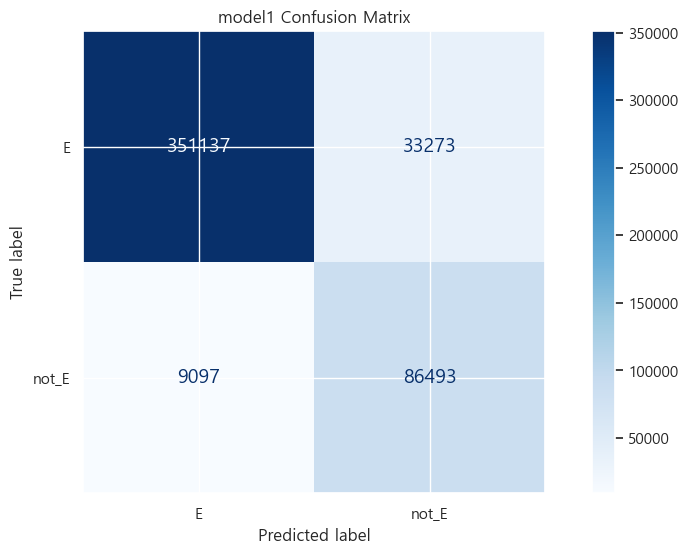

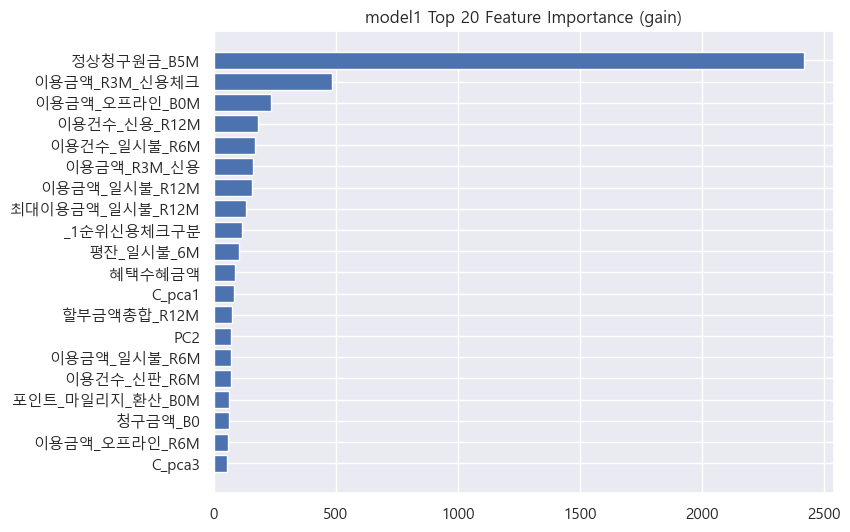

In [42]:
df1 = train_df.copy()
df1['target'] = df1['Segment'].apply(lambda x: 'E' if x == 'E' else 'not_E')

# 다운샘플링 없이 전체 데이터 사용
df1_balanced = df1

model1, map1, imp1 = train_eval_xgb(
    df=df1_balanced,
    features=FEATURES,
    label_col='target',
    model_name='model1'
)


Classification Report for temp_model2
              precision    recall  f1-score   support

           C       0.71      0.82      0.76     25518
           D       0.93      0.88      0.90     69849
       Other       0.85      0.66      0.75       223

    accuracy                           0.86     95590
   macro avg       0.83      0.79      0.80     95590
weighted avg       0.87      0.86      0.87     95590



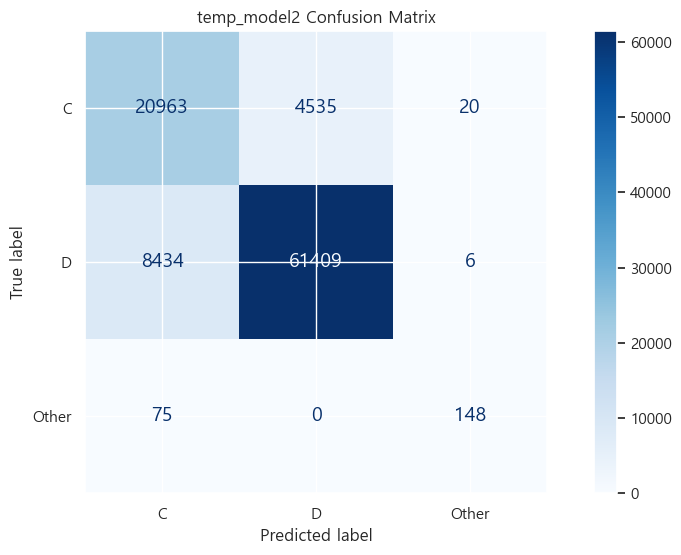

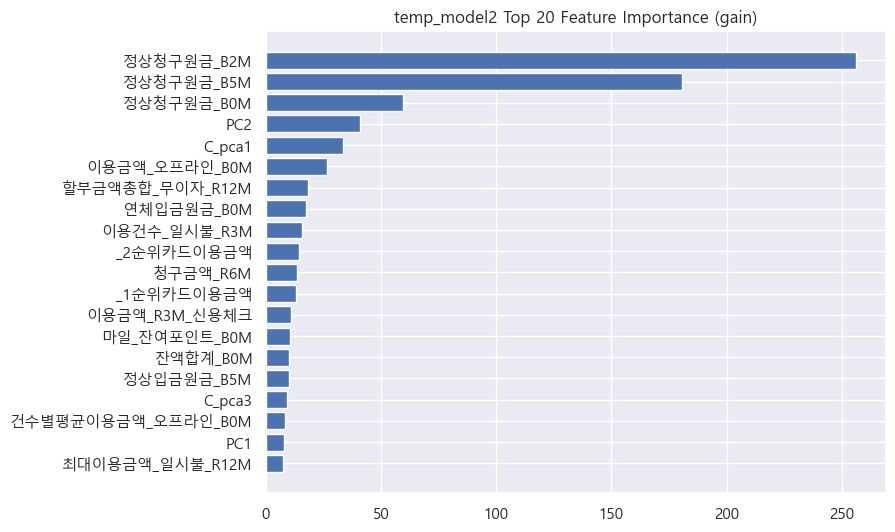

SMOTE 오버샘플링 적용: {0: 250000}

Classification Report for model2
              precision    recall  f1-score   support

           C       0.66      0.85      0.75     25518
           D       0.94      0.84      0.89     69849
       Other       0.88      0.61      0.72       223

    accuracy                           0.85     95590
   macro avg       0.83      0.77      0.79     95590
weighted avg       0.87      0.85      0.85     95590



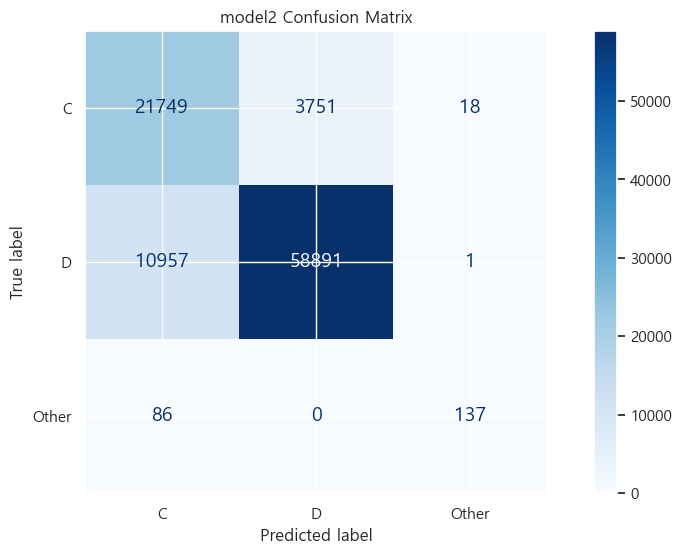

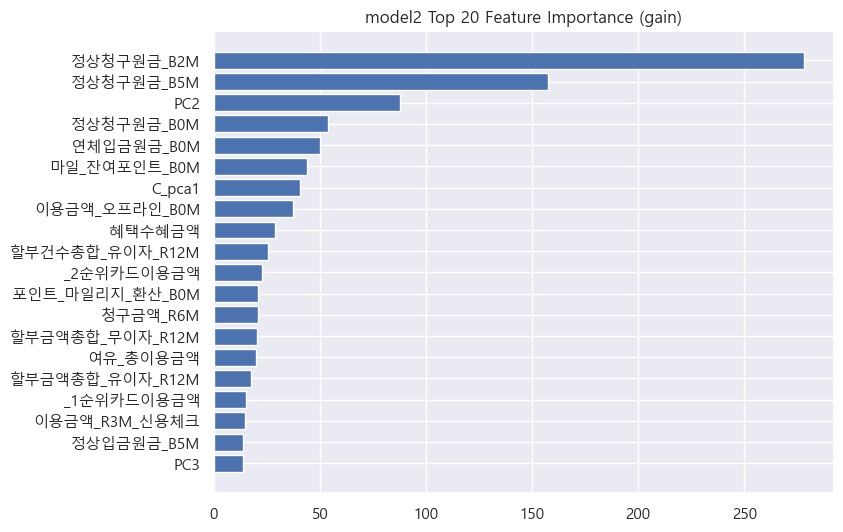

In [43]:
df2 = train_df[train_df['Segment'] != 'E'].copy()
df2['target'] = df2['Segment'].apply(lambda x: x if x in ['C', 'D'] else 'Other')

# 잠깐 임시로 학습 한번 해서 class_map을 먼저 구함
_, temp_map, _ = train_eval_xgb(
    df=df2,
    features=FEATURES,
    label_col='target',
    model_name='temp_model2',
    sampling_strategy=None  # 오버샘플링 없이 일단 실행
)

# 확인된 인코딩 값으로 수정
sampling = {temp_map['C']: 250000}

# 이제 진짜 학습
model2, map2, imp2 = train_eval_xgb(
    df=df2,
    features=FEATURES,
    label_col='target',
    model_name='model2',
    sampling_strategy=sampling
)

SMOTE 오버샘플링 적용: {0: 30000, 1: 30000}

Classification Report for model3
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       195
           B       0.93      0.93      0.93        29

    accuracy                           0.98       224
   macro avg       0.96      0.96      0.96       224
weighted avg       0.98      0.98      0.98       224



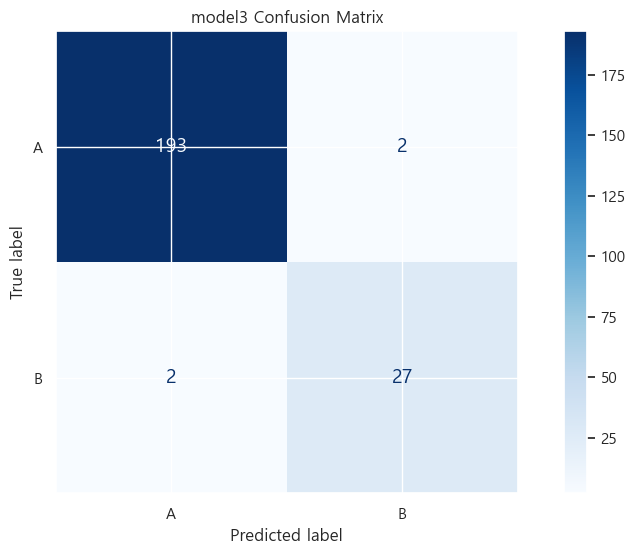

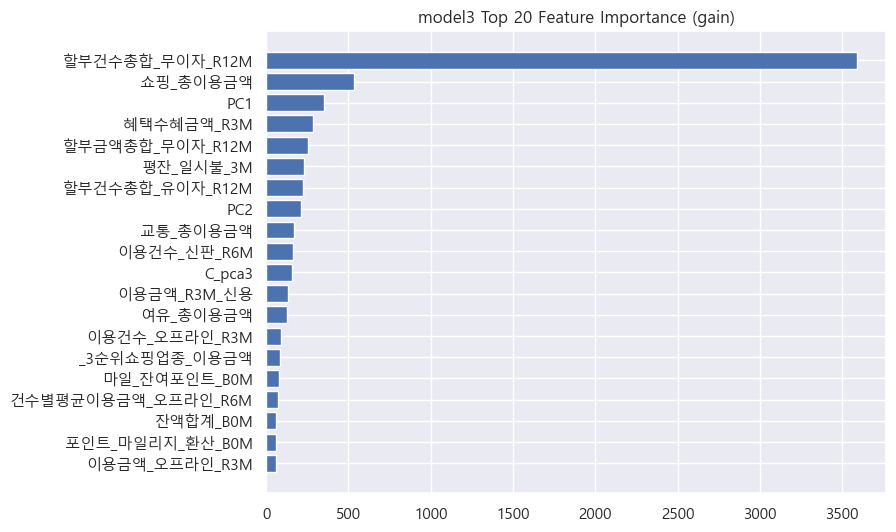

In [44]:
df3 = train_df[train_df['Segment'].isin(['A', 'B'])].copy()
df3['target'] = df3['Segment']

model3, map3, imp3 = train_eval_xgb(
    df=df3,
    features=FEATURES,
    label_col='target',
    model_name='model3',
    sampling_strategy={'A': 30000, 'B': 30000}
)


In [45]:
test_df = pd.read_csv("../data/final_test.csv").reset_index(drop=True)
# ID 컬럼만 불러오기
id_df = pd.read_csv("../data/test/1_회원정보_test.csv", usecols=["ID"])
# 기존 test_df에 ID 컬럼 붙이기 (행 수가 같다는 전제)
test_df["ID"] = id_df["ID"].values

In [46]:
# 모델 불러오기
model1, map1 = joblib.load('./models/model1.pkl')  # E vs not-E
model2, map2 = joblib.load('./models/model2.pkl')  # C vs D vs Other
model3, map3 = joblib.load('./models/model3.pkl')  # A vs B

# 테스트 데이터 로드
#  test_df = pd.read_csv("../data/final_test.csv").reset_index(drop=True)

FEATURES = [col for col in test_df.columns if col not in ["ID", "Segment"]]
X_test = test_df[FEATURES]

# 1단계: E vs not-E
y1_pred = model1.predict(X_test)
inv_map1 = {v: k for k, v in map1.items()}
y1_label = pd.Series(y1_pred, index=test_df.index).map(inv_map1)

# 결과 초기화
final_preds = pd.Series(index=test_df.index, dtype='object')
final_preds[y1_label == 'E'] = 'E'

# 2단계: not-E 데이터 -> C, D, Other(A/B)
idx_not_e = y1_label != 'E'
X_not_e = X_test.loc[idx_not_e]
y2_pred = model2.predict(X_not_e)
inv_map2 = {v: k for k, v in map2.items()}
y2_label = pd.Series(y2_pred, index=X_not_e.index).map(inv_map2)

# C, D는 바로 결과로 확정
final_preds.loc[y2_label.index[y2_label == 'C']] = 'C'
final_preds.loc[y2_label.index[y2_label == 'D']] = 'D'

# 3단계: A/B 분류
idx_ab = y2_label[~y2_label.isin(['C', 'D'])].index
X_ab = X_test.loc[idx_ab]
y3_pred = model3.predict(X_ab)
inv_map3 = {v: k for k, v in map3.items()}
y3_label = pd.Series(y3_pred, index=X_ab.index).map(inv_map3)

# A, B 결과 반영
final_preds.loc[y3_label.index] = y3_label

In [47]:
# 2. 예측 결과 할당
test_df["pred_label"] = final_preds.values  # final_preds: 600,000개의 예측값

# 3. ID별 최빈값 집계
submission = test_df.groupby("ID")["pred_label"] \
    .agg(lambda x: x.value_counts().idxmax()) \
    .reset_index()

submission.columns = ["ID", "Segment"]

# 4. 저장
submission.to_csv("../data/submission_final_3.csv", index=False, encoding="utf-8-sig")
print("10만 명 사용자 기준 최빈값 제출 완료")

10만 명 사용자 기준 최빈값 제출 완료
